# LSTM and TCN: unrestricted 72 h versus manual 42 h

This notebook implements the paper's sequence models on one matched, leakage-safe forecasting task: the next **72 hours / 288 quarter-hour values** at Indusii.

- **Unrestricted 72 h:** 288 rows × all five sensor values; the network can infer lag structure.
- **Manual 42 h:** a 168-row sequence of the paper's four engineered variables (current target, one- and two-hour target change, and Terneuzen shifted by 42 h). The final row is exactly the paper's compact four-feature ablation; extending it as a sequence lets LSTM and TCN operate meaningfully without changing the manual lag hypothesis.
- **Chronology:** January--July train, August validation/calibration, September test.
- **Baseline:** persistence at every lead; models learn only the future change from the most recent target. Skill is compared at 4, 8, 16, 24, and 48 hours as well as over the complete trajectory.

The architecture cells document the improvements made after inspecting `LSTM_salinity_simple_fuseki.ipynb`, `TCN_salinity_simple_fuseki.ipynb`, `TCN_salinity_simple_fuseki_v2.ipynb`, and `tcn_salinity.py`.

In [1]:
from pathlib import Path
import os, sys, time

ROOT = Path.cwd().resolve()
if not (ROOT / "lag_analytics_workspace").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from time_series_analysis.paper_experiment_utils import (
    EVALUATION_HOURS,
    FORECAST_HOURS,
    FORECAST_STEPS,
    build_neural_datasets,
    evaluation_rows,
    load_prepared_observations,
    split_shape_table,
    validation_calibration,
)

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.threading.set_intra_op_parallelism_threads(min(8, os.cpu_count() or 1))
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    pass
print("TensorFlow", tf.__version__, "devices:", tf.config.list_physical_devices())

TensorFlow 2.21.0 devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Matched sequence datasets

In [2]:
data, coverage, unit_report = load_prepared_observations()
datasets = build_neural_datasets(data)
display(coverage)
display(split_shape_table(datasets))

,first observation,last observation,missing after preparation,minimum mS/cm,maximum mS/cm
sensor,,,,,
Terneuzen,2025-01-01 00:00:00+00:00,2026-03-23 15:45:00+00:00,372,0.108207,2.339817
Westdorpe,2025-01-01 00:00:00+00:00,2025-10-07 07:30:00+00:00,257,0.107912,3.997718
Gent - far,2025-01-01 00:00:00+00:00,2026-03-23 12:00:00+00:00,254,0.055390,1.882214
Gent - near,2025-01-01 00:00:00+00:00,2025-12-18 23:00:00+00:00,253,0.068467,1.792810
Indusii,2025-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,962,0.000018,1.945475


,Representation,Split,X shape,y shape,First forecast,Last forecast
0,unrestricted_72h,train,"(3740, 288, 5)","(3740, 288)",2025-01-07 13:45:00+00:00,2025-07-31 23:45:00+00:00
1,unrestricted_72h,validation,"(2098, 288, 5)","(2098, 288)",2025-08-10 03:30:00+00:00,2025-08-31 23:45:00+00:00
2,unrestricted_72h,test,"(2593, 288, 5)","(2593, 288)",2025-09-03 23:45:00+00:00,2025-09-30 23:45:00+00:00
3,manual_42h,train,"(3740, 168, 4)","(3740, 288)",2025-01-07 13:45:00+00:00,2025-07-31 23:45:00+00:00
4,manual_42h,validation,"(2098, 168, 4)","(2098, 288)",2025-08-10 03:30:00+00:00,2025-08-31 23:45:00+00:00
5,manual_42h,test,"(2593, 168, 4)","(2593, 288)",2025-09-03 23:45:00+00:00,2025-09-30 23:45:00+00:00


## 2. Architecture review and revised definitions

The completed baseline run shows why further tuning is justified. The manual TCN reached its best August loss at the final epoch and achieved 0.163 September skill, whereas both unrestricted networks reverted to epoch-one weights and stayed near persistence. The earlier architectures also had avoidable bottlenecks: the LSTM compressed the complete history into one 32-value state, while the TCN retained only its final state. Both then learned all 288 outputs through one small dense layer.

The enhanced encoders preserve last-state information while also pooling the mean and maximum encoded response across the complete history. The LSTM is wider and keeps its second recurrent layer as a sequence. The TCN searches two receptive-field-complete residual configurations. Both use a larger nonlinear forecast head and a small-random output initialization so gradients reach the encoders immediately while the initial forecast remains close to persistence.

Training minimizes **mean squared error**, matching the reported RMSE objective, with AdamW, gradient clipping, smaller batches, learning-rate reduction, and validation-restored early stopping. A deliberately small, predeclared search is selected on August only. `SEARCH_MODE = "recommended"` runs one strong configuration per family; `"quick"` runs two. September is used only after candidate selection. These changes are plausible improvements, not a guarantee that a locally trained network will beat the 119-million-parameter pretrained Chronos-2 model.

In [3]:
L2 = 1e-6
SEARCH_MODE = "quick"  # use "recommended" for one candidate per family
MAX_EPOCHS = 100

CANDIDATES = {
    "LSTM": [
        dict(label="LSTM-96x48", units=(96, 48), dense_units=96, dropout=0.15, learning_rate=3e-4, weight_decay=1e-5, batch_size=64),
        dict(label="LSTM-128x64", units=(128, 64), dense_units=128, dropout=0.20, learning_rate=2e-4, weight_decay=2e-5, batch_size=64),
    ],
    "TCN": [
        dict(label="TCN-32-k5", filters=32, kernel_size=5, dilations=(1, 2, 4, 8, 16, 32), dense_units=128, dropout=0.12, learning_rate=4e-4, weight_decay=1e-5, batch_size=128),
        dict(label="TCN-48-k3", filters=48, kernel_size=3, dilations=(1, 2, 4, 8, 16, 32, 64), dense_units=128, dropout=0.15, learning_rate=3e-4, weight_decay=2e-5, batch_size=128),
    ],
}
if SEARCH_MODE == "recommended":
    ACTIVE_CANDIDATES = {name: configs[:1] for name, configs in CANDIDATES.items()}
elif SEARCH_MODE == "quick":
    ACTIVE_CANDIDATES = CANDIDATES
else:
    raise ValueError('SEARCH_MODE must be either "recommended" or "quick".')


def encoded_summary(sequence, inputs):
    last = layers.Lambda(lambda z: z[:, -1, :], name="encoded_last")(sequence)
    mean = layers.GlobalAveragePooling1D(name="encoded_mean")(sequence)
    maximum = layers.GlobalMaxPooling1D(name="encoded_max")(sequence)
    latest = layers.Lambda(lambda z: z[:, -1, :], name="latest_input")(inputs)
    return layers.Concatenate(name="multi_scale_summary")([last, mean, maximum, latest])


def forecast_head(x, config):
    x = layers.Dense(
        config["dense_units"], activation="swish",
        kernel_regularizer=regularizers.l2(L2), name="forecast_features",
    )(x)
    x = layers.Dropout(config["dropout"], name="forecast_dropout")(x)
    return layers.Dense(
        FORECAST_STEPS, bias_initializer="zeros",
        kernel_initializer=keras.initializers.RandomNormal(stddev=1e-3),
        name="delta_forecast",
    )(x)


def build_lstm(input_shape, config):
    inputs = keras.Input(shape=input_shape, name="history")
    first_units, second_units = config["units"]
    x = layers.LSTM(
        first_units, return_sequences=True,
        kernel_regularizer=regularizers.l2(L2), name="lstm_encoder_1",
    )(inputs)
    x = layers.Dropout(config["dropout"], name="lstm_dropout")(x)
    x = layers.LSTM(
        second_units, return_sequences=True,
        kernel_regularizer=regularizers.l2(L2), name="lstm_encoder_2",
    )(x)
    x = layers.LayerNormalization(name="lstm_normalization")(x)
    outputs = forecast_head(encoded_summary(x, inputs), config)
    return keras.Model(inputs, outputs, name="LSTM_residual_forecaster")


def residual_tcn_block(x, config, dilation):
    shortcut = x
    for conv_number in range(2):
        x = layers.Conv1D(
            config["filters"], config["kernel_size"], padding="causal",
            dilation_rate=dilation, kernel_regularizer=regularizers.l2(L2),
            name=f"d{dilation}_conv{conv_number + 1}",
        )(x)
        x = layers.LayerNormalization(name=f"d{dilation}_norm{conv_number + 1}")(x)
        x = layers.Activation("swish", name=f"d{dilation}_act{conv_number + 1}")(x)
        x = layers.SpatialDropout1D(config["dropout"], name=f"d{dilation}_drop{conv_number + 1}")(x)
    if shortcut.shape[-1] != config["filters"]:
        shortcut = layers.Conv1D(config["filters"], 1, padding="same", name=f"d{dilation}_projection")(shortcut)
    return layers.Activation("swish", name=f"d{dilation}_residual")(layers.Add()([x, shortcut]))


def build_tcn(input_shape, config):
    inputs = keras.Input(shape=input_shape, name="history")
    x = inputs
    for dilation in config["dilations"]:
        x = residual_tcn_block(x, config, dilation)
    outputs = forecast_head(encoded_summary(x, inputs), config)
    return keras.Model(inputs, outputs, name="TCN_residual_forecaster")


BUILDERS = {"LSTM": build_lstm, "TCN": build_tcn}

def compile_model(model, config):
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=config["learning_rate"],
            weight_decay=config["weight_decay"], clipnorm=1.0,
        ),
        loss=keras.losses.MeanSquaredError(),
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae"),
        ],
    )
    return model


for family, configs in ACTIVE_CANDIDATES.items():
    for config in configs:
        preview = BUILDERS[family]((288, 5), config)
        print(f"{config['label']}: {preview.count_params():,} parameters")
        if family == "TCN":
            receptive_field = 1 + 2 * (config["kernel_size"] - 1) * sum(config["dilations"])
            print(f"  receptive field: {receptive_field} steps")
tf.keras.backend.clear_session()


LSTM-96x48: 109,440 parameters
LSTM-128x64: 180,640 parameters
TCN-32-k5: 108,672 parameters
  receptive field: 505 steps
TCN-48-k3: 149,232 parameters
  receptive field: 509 steps


## 3. Train with August-only model selection

Training targets are standardized separately at each lead using January--July only. Batch shuffling changes the order of complete windows, never the order inside a sequence. Each candidate uses August for early stopping and candidate selection. The selected candidate is then evaluated both raw and with the same August-only residual shrinkage used by Chronos-2, making it possible to see whether calibration helps or hurts under September distribution shift.

In [4]:
all_rows, all_horizons, fit_rows, trial_rows = [], [], [], []
predictions, validation_predictions, test_delta_predictions, histories = {}, {}, {}, {}
selected_labels = {}

for representation, dataset in datasets.items():
    train, validation, test = (dataset.splits[name] for name in ("train", "validation", "test"))
    scale = dataset.target_scale
    validation_persistence_rmse = float(np.sqrt(np.mean(validation.y_delta ** 2)))

    for family, builder in BUILDERS.items():
        best_trial = None
        for config in ACTIVE_CANDIDATES[family]:
            tf.keras.backend.clear_session()
            tf.keras.utils.set_random_seed(SEED)
            model = compile_model(builder(train.X.shape[1:], config), config)
            callbacks = [
                keras.callbacks.EarlyStopping(
                    monitor="val_loss", patience=12, min_delta=1e-4,
                    restore_best_weights=True, verbose=1,
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=4,
                    min_lr=1e-6, verbose=1,
                ),
                keras.callbacks.TerminateOnNaN(),
            ]
            print(f"\nTraining {config['label']} on {representation}: {model.count_params():,} parameters")
            started = time.perf_counter()
            history = model.fit(
                train.X, train.y_delta / scale,
                validation_data=(validation.X, validation.y_delta / scale),
                epochs=MAX_EPOCHS, batch_size=config["batch_size"],
                shuffle=True, callbacks=callbacks, verbose=2,
            )
            elapsed = time.perf_counter() - started

            validation_raw = model.predict(validation.X, batch_size=256, verbose=0) * scale
            calibration_weights = validation_calibration(validation_raw, validation.y_delta)
            validation_calibrated = validation_raw * calibration_weights
            raw_rmse = float(np.sqrt(np.mean((validation_raw - validation.y_delta) ** 2)))
            calibrated_rmse = float(np.sqrt(np.mean((validation_calibrated - validation.y_delta) ** 2)))
            trial_rows.append({
                "Family": family, "Candidate": config["label"],
                "Representation": representation, "Parameters": model.count_params(),
                "Epochs": len(history.history["loss"]), "Fit seconds": elapsed,
                "Validation raw RMSE": raw_rmse,
                "Validation calibrated RMSE": calibrated_rmse,
                "Validation calibrated skill": 1 - calibrated_rmse / validation_persistence_rmse,
            })
            if best_trial is None or calibrated_rmse < best_trial["validation_rmse"]:
                best_trial = {
                    "config": config.copy(), "weights": [value.copy() for value in model.get_weights()],
                    "history": history.history, "elapsed": elapsed,
                    "epochs": len(history.history["loss"]),
                    "parameters": model.count_params(), "validation_rmse": calibrated_rmse,
                }
            print(f"Completed in {elapsed:.1f}s; calibrated August RMSE={calibrated_rmse:.5f}")

        selected = best_trial["config"]
        selected_labels[(family, representation)] = selected["label"]
        tf.keras.backend.clear_session()
        selected_model = compile_model(builder(train.X.shape[1:], selected), selected)
        selected_model.set_weights(best_trial["weights"])
        validation_raw = selected_model.predict(validation.X, batch_size=256, verbose=0) * scale
        calibration_weights = validation_calibration(validation_raw, validation.y_delta)
        validation_calibrated = validation_raw * calibration_weights
        test_raw = selected_model.predict(test.X, batch_size=256, verbose=0) * scale
        test_calibrated = test_raw * calibration_weights

        for evaluation_name, predicted_delta in (
            (f"{family} raw", test_raw),
            (f"{family} + Aug calibration", test_calibrated),
        ):
            rows, horizon, prediction = evaluation_rows(
                evaluation_name, representation, test, predicted_delta
            )
            all_rows.extend(rows)
            all_horizons.append(horizon)
            predictions[(evaluation_name, representation)] = prediction

        selected_name = f"{family} + Aug calibration"
        validation_predictions[(family, representation)] = validation_calibrated
        test_delta_predictions[(family, representation)] = test_calibrated
        histories[(family, representation)] = best_trial["history"]
        fit_rows.append({
            "Model": selected_name, "Candidate": selected["label"],
            "Representation": representation, "Parameters": best_trial["parameters"],
            "Epochs": best_trial["epochs"], "Fit seconds": best_trial["elapsed"],
            "Validation RMSE": best_trial["validation_rmse"],
            "Validation persistence RMSE": validation_persistence_rmse,
            "Validation RMSE skill": 1 - best_trial["validation_rmse"] / validation_persistence_rmse,
            "Mean calibration weight": float(calibration_weights.mean()),
        })
        del selected_model

trial_summary = pd.DataFrame(trial_rows).sort_values(
    ["Representation", "Family", "Validation calibrated RMSE"]
)
trial_summary["Selected"] = trial_summary.apply(
    lambda row: row["Candidate"] == selected_labels[(row["Family"], row["Representation"])], axis=1
)
fit_summary = pd.DataFrame(fit_rows).sort_values("Validation RMSE")
results = pd.DataFrame(all_rows)
horizon_results = pd.concat(all_horizons, ignore_index=True)
display(trial_summary.round({
    "Fit seconds": 1, "Validation raw RMSE": 5,
    "Validation calibrated RMSE": 5, "Validation calibrated skill": 3,
}))
display(fit_summary.round({
    "Fit seconds": 1, "Validation RMSE": 5,
    "Validation persistence RMSE": 5, "Validation RMSE skill": 3,
    "Mean calibration weight": 3,
}))


Training LSTM-96x48 on unrestricted_72h: 109,440 parameters
Epoch 1/100
59/59 - 13s - 222ms/step - loss: 0.9755 - mae: 0.4830 - rmse: 0.9875 - val_loss: 15.2679 - val_mae: 2.2087 - val_rmse: 3.9074 - learning_rate: 3.0000e-04
Epoch 2/100
59/59 - 10s - 173ms/step - loss: 0.8895 - mae: 0.4635 - rmse: 0.9430 - val_loss: 15.1893 - val_mae: 2.2474 - val_rmse: 3.8973 - learning_rate: 3.0000e-04
Epoch 3/100
59/59 - 10s - 177ms/step - loss: 0.7999 - mae: 0.4427 - rmse: 0.8942 - val_loss: 14.9794 - val_mae: 2.3219 - val_rmse: 3.8703 - learning_rate: 3.0000e-04
Epoch 4/100
59/59 - 10s - 170ms/step - loss: 0.7182 - mae: 0.4327 - rmse: 0.8473 - val_loss: 14.6892 - val_mae: 2.3516 - val_rmse: 3.8326 - learning_rate: 3.0000e-04
Epoch 5/100
59/59 - 10s - 171ms/step - loss: 0.6630 - mae: 0.4239 - rmse: 0.8141 - val_loss: 14.3445 - val_mae: 2.2906 - val_rmse: 3.7874 - learning_rate: 3.0000e-04
Epoch 6/100
59/59 - 10s - 171ms/step - loss: 0.6283 - mae: 0.4182 - rmse: 0.7925 - val_loss: 13.9655 - val_ma

,Family,Candidate,Representation,Parameters,Epochs,Fit seconds,Validation raw RMSE,Validation calibrated RMSE,Validation calibrated skill,Selected
4,LSTM,LSTM-96x48,manual_42h,108960,28,191.4,0.26018,0.26018,0.186,True
5,LSTM,LSTM-128x64,manual_42h,180000,30,305.4,0.26412,0.26412,0.173,False
7,TCN,TCN-48-k3,manual_42h,148912,48,358.3,0.26520,0.26514,0.170,True
6,TCN,TCN-32-k5,manual_42h,108352,37,164.9,0.26580,0.26573,0.168,False
1,LSTM,LSTM-128x64,unrestricted_72h,180640,60,917.3,0.27070,0.27070,0.153,True
0,LSTM,LSTM-96x48,unrestricted_72h,109440,28,294.6,0.28657,0.28657,0.103,False
2,TCN,TCN-32-k5,unrestricted_72h,108672,52,379.7,0.28314,0.28314,0.114,True
3,TCN,TCN-48-k3,unrestricted_72h,149232,27,368.3,0.29064,0.29064,0.090,False


,Model,Candidate,Representation,Parameters,Epochs,Fit seconds,Validation RMSE,Validation persistence RMSE,Validation RMSE skill,Mean calibration weight
2,LSTM + Aug calibration,LSTM-96x48,manual_42h,108960,28,191.4,0.26018,0.31953,0.186,1.000
3,TCN + Aug calibration,TCN-48-k3,manual_42h,148912,48,358.3,0.26514,0.31953,0.170,0.989
0,LSTM + Aug calibration,LSTM-128x64,unrestricted_72h,180640,60,917.3,0.27070,0.31953,0.153,1.000
1,TCN + Aug calibration,TCN-32-k5,unrestricted_72h,108672,52,379.7,0.28314,0.31953,0.114,1.000


## 4. Validation-prespecified ensemble

LSTM and TCN capture different dependencies. Instead of assuming a 50/50 average—which weakened the best TCN in the completed baseline run—the notebook selects one **global convex blend weight** from the predeclared grid `{0.00, 0.05, ..., 1.00}` using August RMSE only. A global weight is intentionally more conservative than fitting 288 separate lead-specific weights. September remains untouched until the final scoring call.

In [5]:
BLEND_GRID = np.linspace(0.0, 1.0, 21)

for representation, dataset in datasets.items():
    validation, test = dataset.splits["validation"], dataset.splits["test"]
    validation_lstm = validation_predictions[("LSTM", representation)]
    validation_tcn = validation_predictions[("TCN", representation)]
    blend_rmse = []
    for lstm_weight in BLEND_GRID:
        candidate = lstm_weight * validation_lstm + (1 - lstm_weight) * validation_tcn
        blend_rmse.append(float(np.sqrt(np.mean((candidate - validation.y_delta) ** 2))))
    best_index = int(np.argmin(blend_rmse))
    lstm_weight = float(BLEND_GRID[best_index])
    validation_ensemble = lstm_weight * validation_lstm + (1 - lstm_weight) * validation_tcn
    test_ensemble = (
        lstm_weight * test_delta_predictions[("LSTM", representation)]
        + (1 - lstm_weight) * test_delta_predictions[("TCN", representation)]
    )
    validation_persistence_rmse = float(np.sqrt(np.mean(validation.y_delta ** 2)))
    validation_rmse = float(np.sqrt(np.mean((validation_ensemble - validation.y_delta) ** 2)))
    rows, horizon, prediction = evaluation_rows(
        "LSTM+TCN validation blend", representation, test, test_ensemble
    )
    all_rows.extend(rows)
    all_horizons.append(horizon)
    predictions[("LSTM+TCN validation blend", representation)] = prediction
    fit_rows.append({
        "Model": "LSTM+TCN validation blend",
        "Candidate": f"LSTM weight={lstm_weight:.2f}",
        "Representation": representation,
        "Parameters": np.nan, "Epochs": np.nan, "Fit seconds": 0.0,
        "Validation RMSE": validation_rmse,
        "Validation persistence RMSE": validation_persistence_rmse,
        "Validation RMSE skill": 1 - validation_rmse / validation_persistence_rmse,
        "Mean calibration weight": np.nan,
    })

fit_summary = pd.DataFrame(fit_rows).sort_values("Validation RMSE")
results = pd.DataFrame(all_rows)
horizon_results = pd.concat(all_horizons, ignore_index=True)
display(fit_summary[fit_summary["Model"] == "LSTM+TCN validation blend"].round({
    "Validation RMSE": 5, "Validation persistence RMSE": 5,
    "Validation RMSE skill": 3,
}))

,Model,Candidate,Representation,Parameters,Epochs,Fit seconds,Validation RMSE,Validation persistence RMSE,Validation RMSE skill,Mean calibration weight
5,LSTM+TCN validation blend,LSTM weight=1.00,manual_42h,NaN,NaN,0.0,0.26018,0.31953,0.186,NaN
4,LSTM+TCN validation blend,LSTM weight=1.00,unrestricted_72h,NaN,NaN,0.0,0.27070,0.31953,0.153,NaN


## 5. Held-out September results

In [6]:
summary = results.pivot_table(
    index=["Model", "Representation"], columns="Scope",
    values=["RMSE", "R2", "RMSE skill"]
).sort_values(("RMSE", "all horizons"))
display(summary.round(4))

checkpoint_scopes = [f"{hours}-hour mark" for hours in EVALUATION_HOURS]
checkpoint_skill = (
    results[results["Scope"].isin(checkpoint_scopes)]
    .pivot(index=["Model", "Representation"], columns="Scope", values="RMSE skill")
    .reindex(columns=checkpoint_scopes)
)
display(checkpoint_skill.round(4))

R2               \
Scope                                      16-hour mark 24-hour mark   
Model                     Representation                               
TCN raw                   manual_42h             0.0534       0.1217   
TCN + Aug calibration     manual_42h             0.0534       0.1217   
LSTM raw                  manual_42h            -0.0098       0.0383   
LSTM+TCN validation blend manual_42h            -0.0098       0.0383   
LSTM + Aug calibration    manual_42h            -0.0098       0.0383   
TCN + Aug calibration     unrestricted_72h      -0.0417       0.0358   
TCN raw                   unrestricted_72h      -0.0417       0.0358   
LSTM + Aug calibration    unrestricted_72h      -0.1632      -0.2132   
LSTM+TCN validation blend unrestricted_72h      -0.1632      -0.2132   
LSTM raw                  unrestricted_72h      -0.1632      -0.2132   

                                                                     \
Scope                                      4-hour mark 48-hour mark   
Model                     Representation                              
TCN raw                   manual_42h            0.2909      -0.0039   
TCN + Aug calibration     manual_42h            0.2909      -0.0039   
LSTM raw                  manual_42h            0.2725      -0.0819   
LSTM+TCN validation blend manual_42h            0.2725      -0.0819   
LSTM + Aug calibration    manual_42h            0.2725      -0.0819   
TCN + Aug calibration     unrestricted_72h      0.2391      -0.1046   
TCN raw                   unrestricted_72h      0.2391      -0.1046   
LSTM + Aug calibration    unrestricted_72h      0.2445      -0.1580   
LSTM+TCN validation blend unrestricted_72h      0.2445      -0.1580   
LSTM raw                  unrestricted_72h      0.2445      -0.1580   

                                                                     \
Scope                                      8-hour mark all horizons   
Model                     Representation                              
TCN raw                   manual_42h            0.1972       0.0684   
TCN + Aug calibration     manual_42h            0.1855       0.0663   
LSTM raw                  manual_42h            0.1724      -0.0016   
LSTM+TCN validation blend manual_42h            0.1724      -0.0017   
LSTM + Aug calibration    manual_42h            0.1724      -0.0017   
TCN + Aug calibration     unrestricted_72h      0.1320      -0.0325   
TCN raw                   unrestricted_72h      0.1320      -0.0325   
LSTM + Aug calibration    unrestricted_72h      0.0840      -0.1607   
LSTM+TCN validation blend unrestricted_72h      0.0840      -0.1607   
LSTM raw                  unrestricted_72h      0.0840      -0.1607   

                                                                       RMSE  \
Scope                                      largest 10% changes 16-hour mark   
Model                     Representation                                      
TCN raw                   manual_42h                   -0.6133       0.2795   
TCN + Aug calibration     manual_42h                   -0.6230       0.2795   
LSTM raw                  manual_42h                   -0.6939       0.2887   
LSTM+TCN validation blend manual_42h                   -0.6943       0.2887   
LSTM + Aug calibration    manual_42h                   -0.6943       0.2887   
TCN + Aug calibration     unrestricted_72h             -0.9812       0.2932   
TCN raw                   unrestricted_72h             -0.9812       0.2932   
LSTM + Aug calibration    unrestricted_72h             -0.8590       0.3099   
LSTM+TCN validation blend unrestricted_72h             -0.8590       0.3099   
LSTM raw                  unrestricted_72h             -0.8590       0.3099   

                                                                     ...  \
Scope                                      24-hour mark 4-hour mark  ...   
Model                     Representation                             ...   
TCN raw     

Scope                                       4-hour mark  8-hour mark  \
Model                     Representation                               
LSTM + Aug calibration    manual_42h             0.1338       0.1386   
                          unrestricted_72h       0.1173       0.0938   
LSTM raw                  manual_42h             0.1338       0.1386   
                          unrestricted_72h       0.1173       0.0938   
LSTM+TCN validation blend manual_42h             0.1338       0.1386   
                          unrestricted_72h       0.1173       0.0938   
TCN + Aug calibration     manual_42h             0.1448       0.1455   
                          unrestricted_72h       0.1141       0.1179   
TCN raw                   manual_42h             0.1448       0.1516   
                          unrestricted_72h       0.1141       0.1179   

Scope                                       16-hour mark  24-hour mark  \
Model                     Representation                                 
LSTM + Aug calibration    manual_42h              0.1520        0.1540   
                          unrestricted_72h        0.0898        0.0498   
LSTM raw                  manual_42h              0.1520        0.1540   
                          unrestricted_72h        0.0898        0.0498   
LSTM+TCN validation blend manual_42h              0.1520        0.1540   
                          unrestricted_72h        0.0898        0.0498   
TCN + Aug calibration     manual_42h              0.1789        0.1915   
                          unrestricted_72h        0.1387        0.1529   
TCN raw                   manual_42h              0.1789        0.1915   
                          unrestricted_72h        0.1387        0.1529   

Scope                                       48-hour mark  
Model                     Representation                  
LSTM + Aug calibration    manual_42h              0.1529  
                          unrestricted_72h        0.1236  
LSTM raw                  manual_42h              0.1529  
                          unrestricted_72h        0.1236  
LSTM+TCN validation blend manual_42h              0.1529  
                          unrestricted_72h        0.1236  
TCN + Aug calibration     manual_42h              0.1840  
                          unrestricted_72h        0.1440  
TCN raw                   manual_42h              0.1840  
                          unrestricted_72h        0.1440

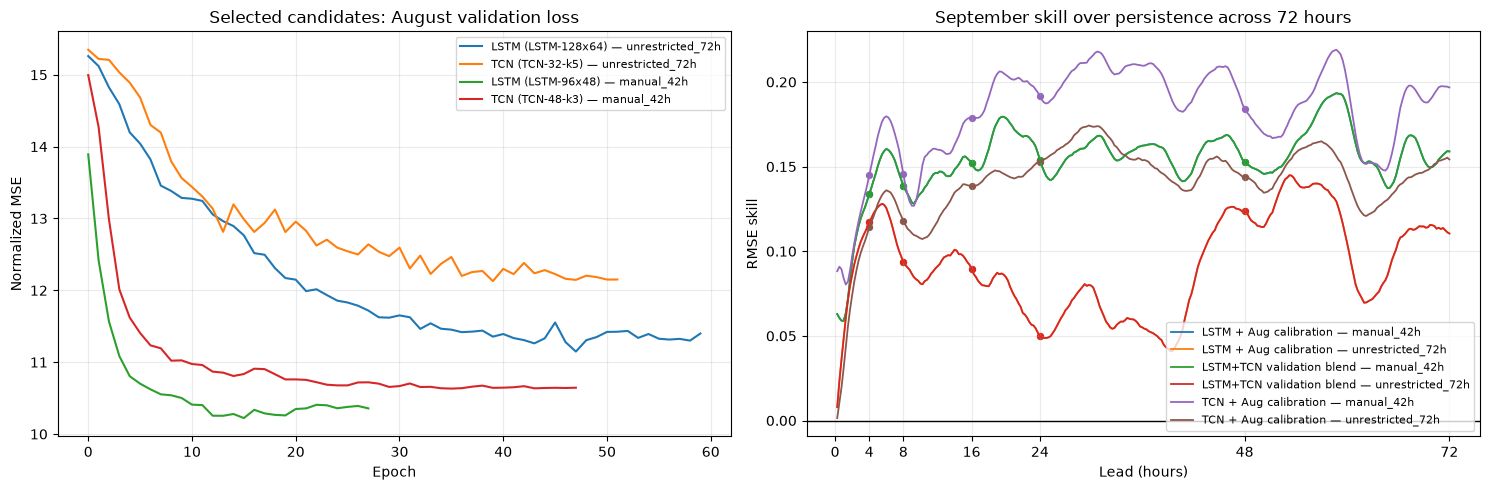

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for key, history in histories.items():
    label = f"{key[0]} ({selected_labels[key]}) — {key[1]}"
    axes[0].plot(history["val_loss"], label=label)
axes[0].set(title="Selected candidates: August validation loss", xlabel="Epoch", ylabel="Normalized MSE")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=.25)

plot_models = {"LSTM + Aug calibration", "TCN + Aug calibration", "LSTM+TCN validation blend"}
for (model_name, representation), group in horizon_results[
    horizon_results["Model"].isin(plot_models)
].groupby(["Model", "Representation"]):
    axes[1].plot(group["Lead hours"], group["RMSE skill"], linewidth=1.3, label=f"{model_name} — {representation}")
    marked = group[group["Lead hours"].isin(EVALUATION_HOURS)]
    axes[1].scatter(marked["Lead hours"], marked["RMSE skill"], s=18)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title=f"September skill over persistence across {FORECAST_HOURS} hours", xlabel="Lead (hours)", ylabel="RMSE skill")
axes[1].set_xticks([0, *EVALUATION_HOURS, FORECAST_HOURS])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()

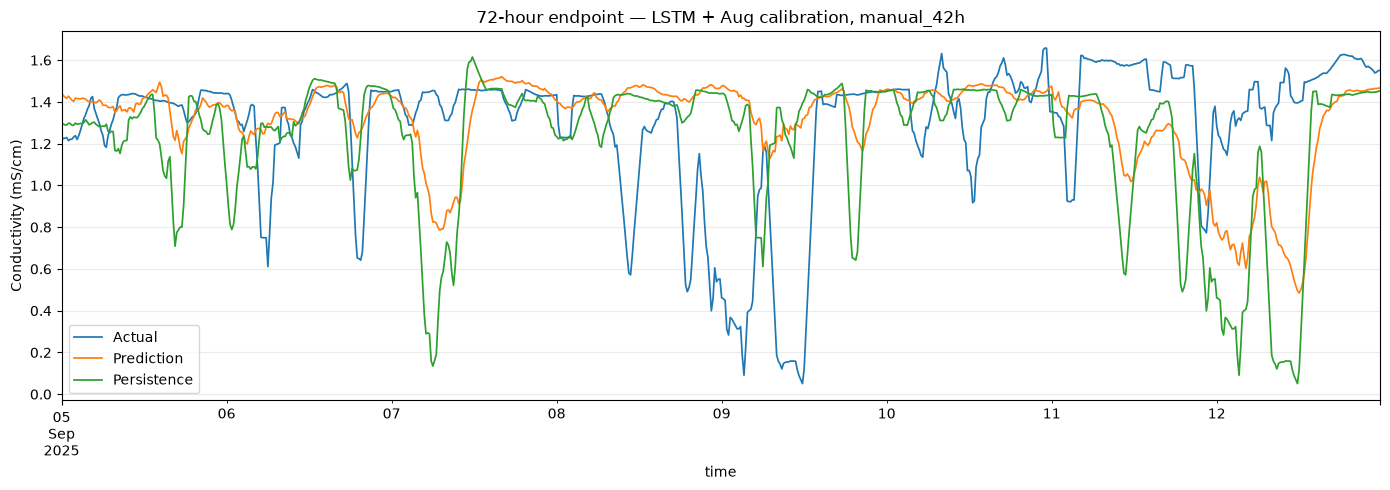

In [8]:
# Choose the illustration by August validation RMSE only.
best_row = fit_summary.iloc[0]
best_key = (best_row["Model"], best_row["Representation"])
week = predictions[best_key].loc["2025-09-05":"2025-09-12"]
ax = week.plot(figsize=(14, 5), linewidth=1.25)
ax.set_title(f"{FORECAST_HOURS}-hour endpoint — {best_key[0]}, {best_key[1]}")
ax.set_ylabel("Conductivity (mS/cm)")
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 6. Reproducible conclusion

In [9]:
for representation in datasets:
    chosen = fit_summary[fit_summary["Representation"] == representation].iloc[0]
    row = results[
        (results["Model"] == chosen["Model"]) &
        (results["Representation"] == representation) &
        (results["Scope"] == "all horizons")
    ].iloc[0]
    checkpoint_rows = results[
        (results["Model"] == chosen["Model"])
        & (results["Representation"] == representation)
        & (results["Scope"].isin(checkpoint_scopes))
    ].set_index("Scope")
    checkpoint_text = ", ".join(
        f"{hours} h={checkpoint_rows.loc[f'{hours}-hour mark', 'RMSE skill']:.3f}"
        for hours in EVALUATION_HOURS
    )
    print(
        f"{representation}: August selected {chosen['Model']}; "
        f"September RMSE={row['RMSE']:.5f}, overall {FORECAST_HOURS}-hour skill={row['RMSE skill']:.3f}; "
        f"checkpoint skill: {checkpoint_text}."
    )

best_test = results[results["Scope"] == "all horizons"].sort_values("RMSE").iloc[0]
print(
    f"\nLowest September RMSE among the pre-specified neural experiments: "
    f"{best_test['Model']} with {best_test['Representation']} "
    f"({best_test['RMSE']:.5f}; skill {best_test['RMSE skill']:.3f})."
)

unrestricted_72h: August selected LSTM + Aug calibration; September RMSE=0.30554, overall 72-hour skill=0.092; checkpoint skill: 4 h=0.117, 8 h=0.094, 16 h=0.090, 24 h=0.050, 48 h=0.124.
manual_42h: August selected LSTM + Aug calibration; September RMSE=0.28385, overall 72-hour skill=0.157; checkpoint skill: 4 h=0.134, 8 h=0.139, 16 h=0.152, 24 h=0.154, 48 h=0.153.

Lowest September RMSE among the pre-specified neural experiments: TCN raw with manual_42h (0.27374; skill 0.187).
